# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Banknote Authentication Dataset**, yang bersumber dari UCI Machine Learning Repository.

Dataset ini terdiri dari **1372 sampel** uang kertas yang diekstraksi dari gambar beresolusi tinggi.
Setiap sampel memiliki 4 fitur numerik:
| Fitur | Deskripsi |
|---|---|
| variance | Variansi dari transformasi Wavelet |
| skewness | Skewness dari transformasi Wavelet |
| curtosis | Kurtosis dari transformasi Wavelet |
| entropy | Entropi dari gambar uang kertas |

**Tujuan**: Membangun model klasifikasi untuk membedakan uang kertas asli (class 0) dan palsu (class 1) berdasarkan keempat fitur tersebut.


# **2. Import Library**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

import os

print('Library berhasil diimpor!')


Library berhasil diimpor!


# **3. Memuat Dataset**

In [2]:
# Load dataset Banknote Authentication
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
column_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, names=column_names)
df['class_name'] = df['class'].map({0: 'asli', 1: 'palsu'})

# Simpan raw dataset
os.makedirs('banknote_raw', exist_ok=True)
df.to_csv('banknote_raw/banknote_raw.csv', index=False)
print('Raw dataset disimpan ke banknote_raw/banknote_raw.csv')

# Preview data
print(f'\nShape dataset: {df.shape}')
df.head(10)


Raw dataset disimpan ke banknote_raw/banknote_raw.csv

Shape dataset: (1372, 6)


,variance,skewness,curtosis,entropy,class,class_name
0,3.62160,8.6661,-2.80730,-0.44699,0,asli
1,4.54590,8.1674,-2.45860,-1.46210,0,asli
2,3.86600,-2.6383,1.92420,0.10645,0,asli
3,3.45660,9.5228,-4.01120,-3.59440,0,asli
4,0.32924,-4.4552,4.57180,-0.98880,0,asli
5,4.36840,9.6718,-3.96060,-3.16250,0,asli
6,3.59120,3.0129,0.72888,0.56421,0,asli
7,2.09220,-6.8100,8.46360,-0.60216,0,asli
8,3.20320,5.7588,-0.75345,-0.61251,0,asli
9,1.53560,9.1772,-2.27180,-0.73535,0,asli


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   variance    1372 non-null   float64
 1   skewness    1372 non-null   float64
 2   curtosis    1372 non-null   float64
 3   entropy     1372 non-null   float64
 4   class       1372 non-null   int64  
 5   class_name  1372 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 64.4+ KB


In [4]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


# **4. Exploratory Data Analysis (EDA)**

## 4.1 Pengecekan Missing Values dan Duplikasi

In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

print(f'\n=== Duplikasi ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')


=== Missing Values ===
variance      0
skewness      0
curtosis      0
entropy       0
class         0
class_name    0
dtype: int64

Total missing values: 0

=== Duplikasi ===
Jumlah baris duplikat: 24


## 4.2 Distribusi Kelas (Target)

=== Distribusi Kelas ===
class_name
asli     762
palsu    610
Name: count, dtype: int64


C:\Users\monar\AppData\Local\Temp\ipykernel_9964\3573422088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class_name', palette='Set2')


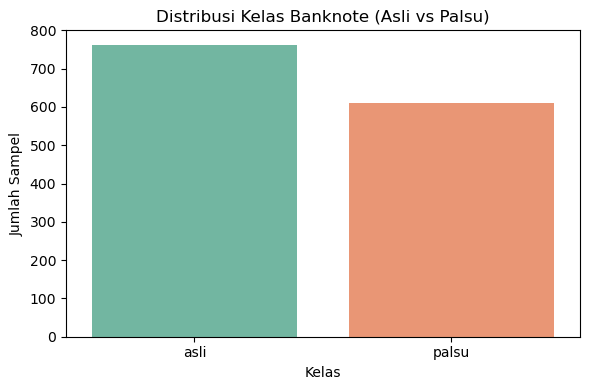

In [6]:
print('=== Distribusi Kelas ===')
print(df['class_name'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class_name', palette='Set2')
plt.title('Distribusi Kelas Banknote (Asli vs Palsu)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()


## 4.3 Distribusi Fitur

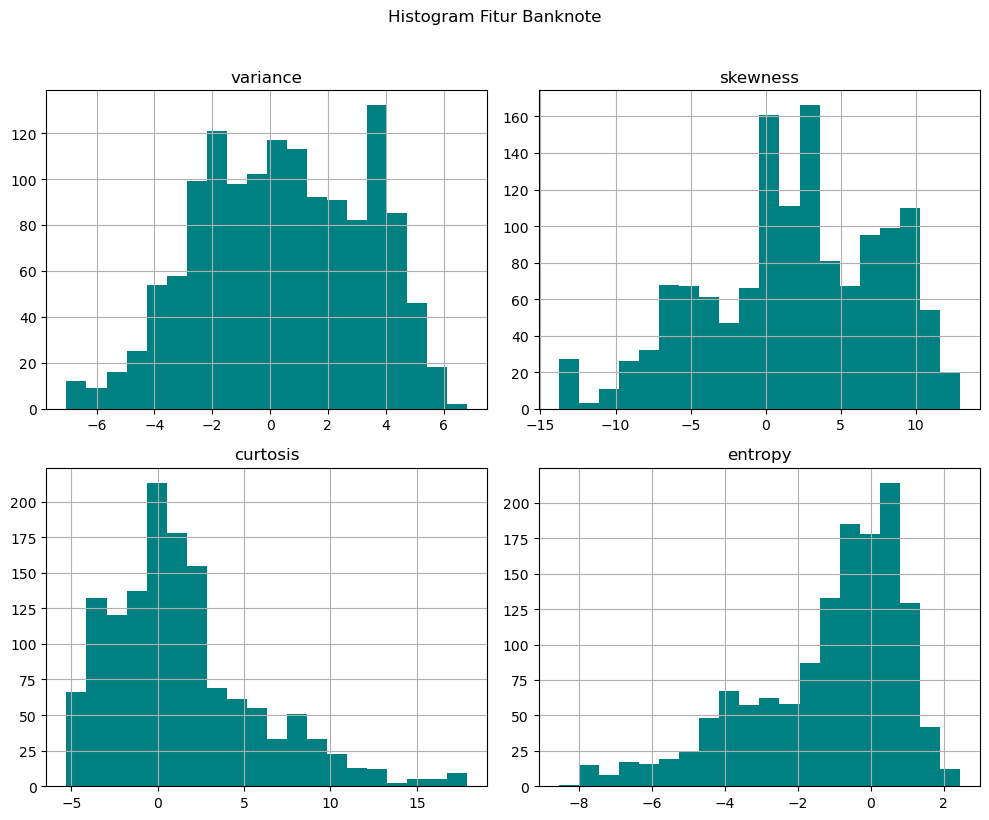

In [7]:
features = ['variance', 'skewness', 'curtosis', 'entropy']
df[features].hist(bins=20, figsize=(10, 8), color='teal')
plt.suptitle('Histogram Fitur Banknote', y=1.02)
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

In [8]:
# Menghapus duplikasi
df = df.drop_duplicates()
print(f'Shape dataset setelah hapus duplikat: {df.shape}')

# Menghapus kolom class_name karena tidak diperlukan untuk modelling
df = df.drop(columns=['class_name'])

# Simpan hasil preprocessing secara utuh (tanpa split)
os.makedirs('preprocessing/banknote_preprocessing', exist_ok=True)
df.to_csv('preprocessing/banknote_preprocessing/banknote_preprocessed.csv', index=False)

print('Data preprocessing (bersih) berhasil disimpan!')
df.head()


Shape dataset setelah hapus duplikat: (1348, 6)
Data preprocessing (bersih) berhasil disimpan!


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0
